In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [57]:
df = pd.read_csv("../data/processed/train.csv")
df.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,63.531377,10,Sci-Fi,2.176498,4,Male,3,No,No,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,25.725595,18,Action,3.478632,8,Male,23,No,Yes,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,57.364061,23,Fantasy,4.238824,6,Male,1,Yes,Yes,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,131.537507,30,Drama,4.276013,2,Male,24,Yes,Yes,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,45.356653,20,Comedy,3.616170,4,Female,0,No,No,0


# Feature vs Target Visualizations

In [58]:
# Let's look at the relationship between AccountAge and Churn

In [59]:
account_age_dist = (
    df.groupby("AccountAge")
      .agg(
          churn_rate=("Churn", "mean"),
          customer_count=("Churn", "size")
      )
      .reset_index()
)

In [60]:
account_age_dist

,AccountAge,churn_rate,customer_count
0,1,0.328536,2015
1,2,0.321991,1969
2,3,0.322404,2013
3,4,0.340237,2028
4,5,0.323335,1967
...,...,...,...
114,115,0.074864,2017
115,116,0.078004,2064
116,117,0.081801,2066
117,118,0.072211,2008


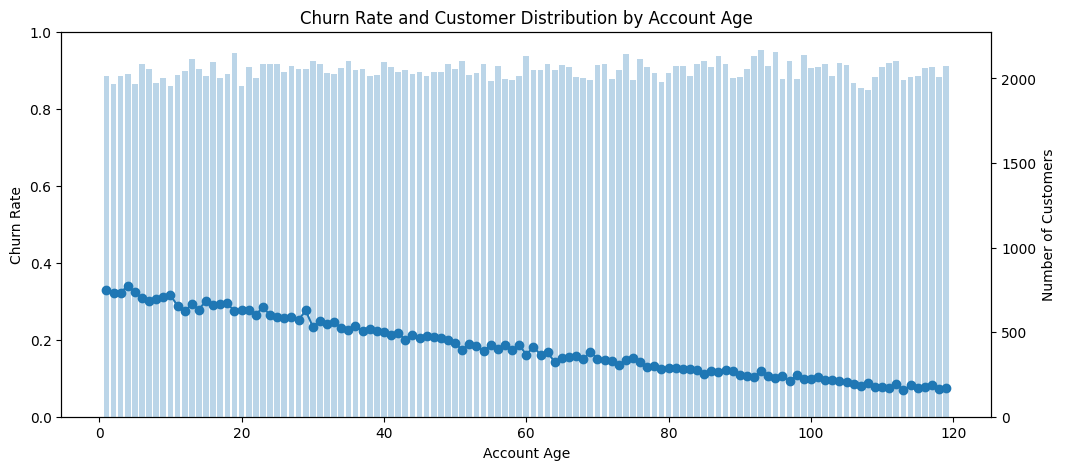

In [61]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(
    account_age_dist["AccountAge"],
    account_age_dist["churn_rate"],
    marker="o"
)

ax1.set_xlabel("Account Age")
ax1.set_ylabel("Churn Rate")
ax1.set_ylim(0,1)

ax2 = ax1.twinx()

ax2.bar(
    account_age_dist["AccountAge"],
    account_age_dist["customer_count"],
    alpha=0.3
)

ax2.set_ylabel("Number of Customers")

plt.title("Churn Rate and Customer Distribution by Account Age")

plt.show()

In [62]:
# As the account age grows, churn rate is doing down.

---

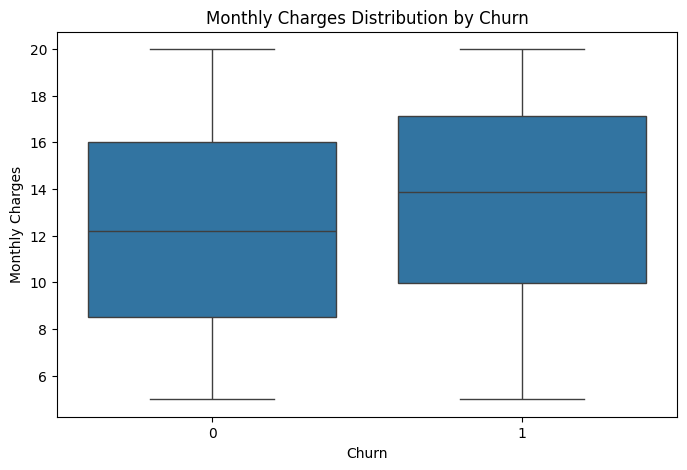

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

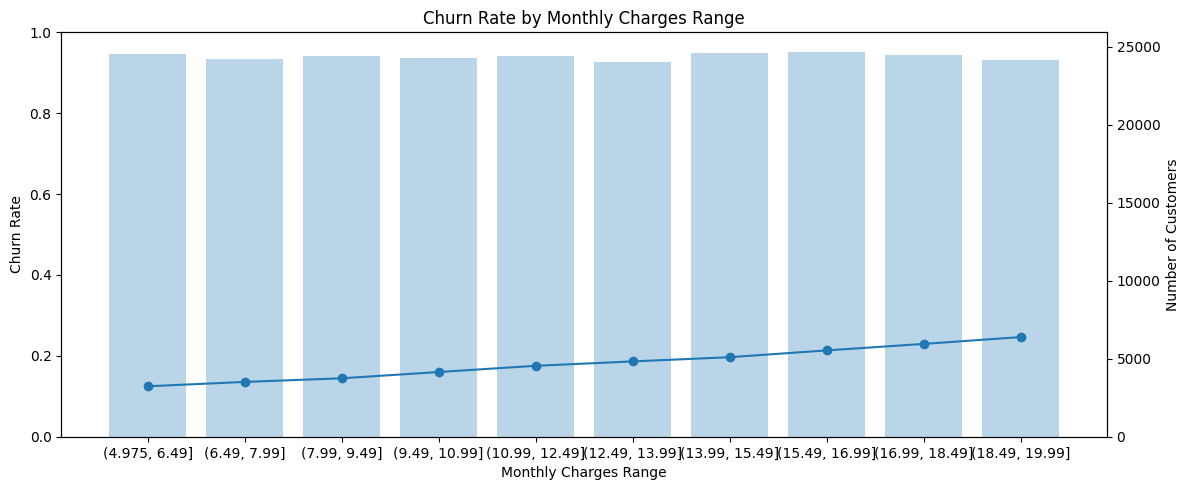

In [64]:
import matplotlib.pyplot as plt

monthly_charges_dist = (
    df.assign(
        MonthlyChargesGroup=pd.cut(
            df["MonthlyCharges"],
            bins=10
        )
    )
    .groupby("MonthlyChargesGroup", observed=True)
    .agg(
        churn_rate=("Churn", "mean"),
        customer_count=("Churn", "size")
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(
    monthly_charges_dist["MonthlyChargesGroup"].astype(str),
    monthly_charges_dist["churn_rate"],
    marker="o"
)

ax1.set_xlabel("Monthly Charges Range")
ax1.set_ylabel("Churn Rate")
ax1.set_ylim(0,1)

ax2 = ax1.twinx()

ax2.bar(
    monthly_charges_dist["MonthlyChargesGroup"].astype(str),
    monthly_charges_dist["customer_count"],
    alpha=0.3
)

ax2.set_ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.title("Churn Rate by Monthly Charges Range")
plt.tight_layout()

plt.show()

In [65]:
# Customers who churn have a higher median monthly charge compared to customers who stay, suggesting that higher monthly costs may increase churn probability

In [66]:
df.groupby("Churn")["MonthlyCharges"].agg(
    ["mean", "median", "std"]
)

,mean,median,std
Churn,,,
0,12.286129,12.189954,4.317675
1,13.414880,13.855745,4.251322


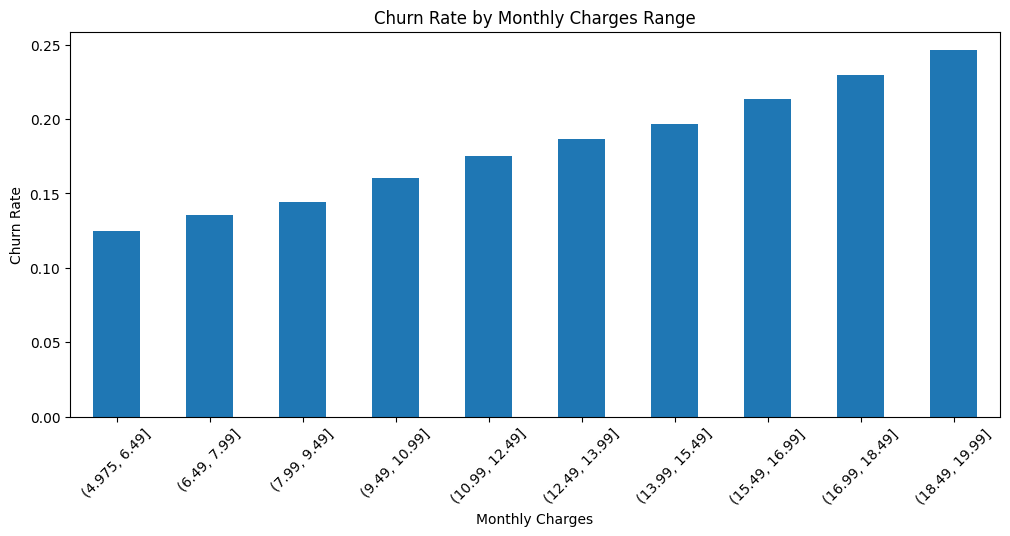

In [67]:
df["MonthlyChargesGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=10
)

monthly_churn = (
    df.groupby("MonthlyChargesGroup", observed=True)["Churn"]
      .mean()
)

monthly_churn.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Churn Rate")
plt.xlabel("Monthly Charges")
plt.title("Churn Rate by Monthly Charges Range")

plt.xticks(rotation=45)
plt.show()

In [68]:
df[["MonthlyCharges", "Churn"]].corr()

,MonthlyCharges,Churn
MonthlyCharges,1.000000,0.100473
Churn,0.100473,1.000000


---

In [69]:
subscription_churn = (
    df.groupby("SubscriptionType")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

subscription_churn

SubscriptionType
Basic       0.196521
Standard    0.184314
Premium     0.162775
Name: Churn, dtype: float64

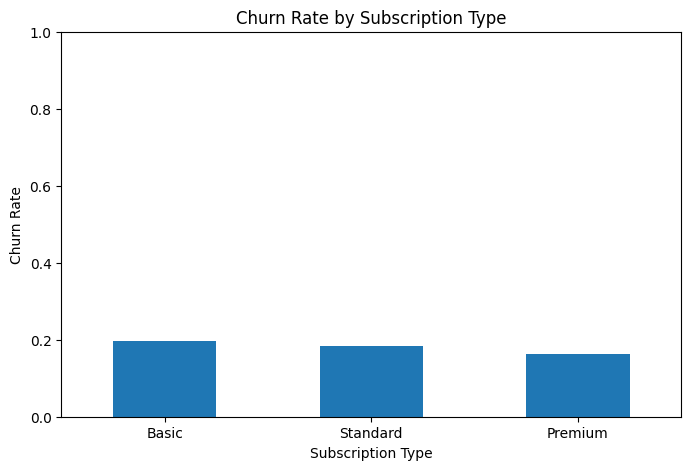

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

subscription_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("Subscription Type")
plt.title("Churn Rate by Subscription Type")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()

---

In [71]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

payment_churn

PaymentMethod
Electronic check    0.192471
Mailed check        0.190888
Bank transfer       0.179269
Credit card         0.162251
Name: Churn, dtype: float64

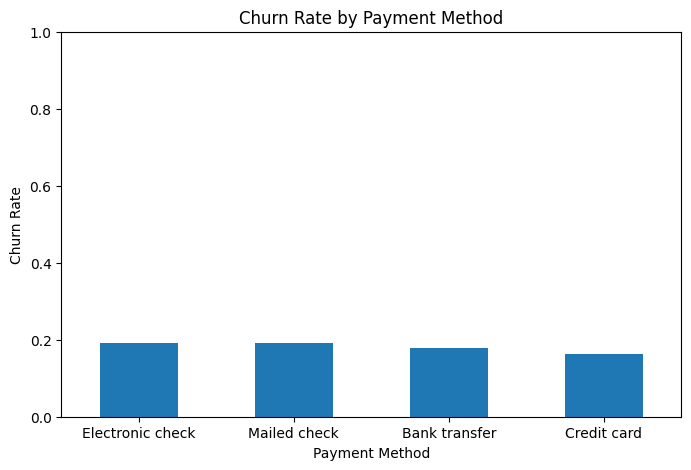

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

payment_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("Payment Method")
plt.title("Churn Rate by Payment Method")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()

---

PaperlessBilling
No     0.181587
Yes    0.180876
Name: Churn, dtype: float64


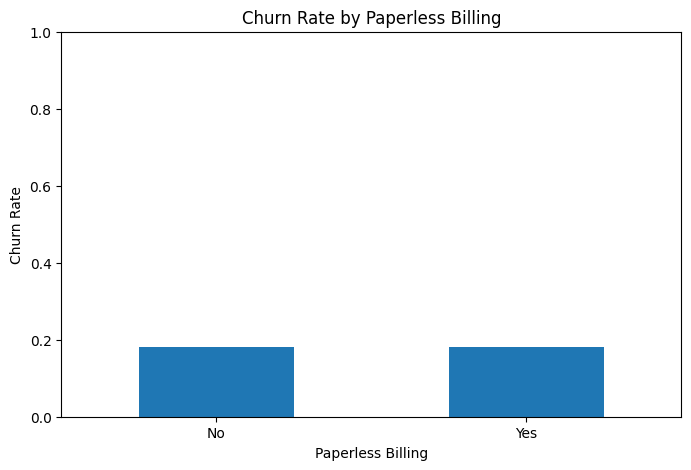

In [73]:
paperless_churn = (
    df.groupby("PaperlessBilling")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

print(paperless_churn)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

paperless_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("Paperless Billing")
plt.title("Churn Rate by Paperless Billing")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()

---

ContentType
Both        0.188470
Movies      0.177764
TV Shows    0.177398
Name: Churn, dtype: float64


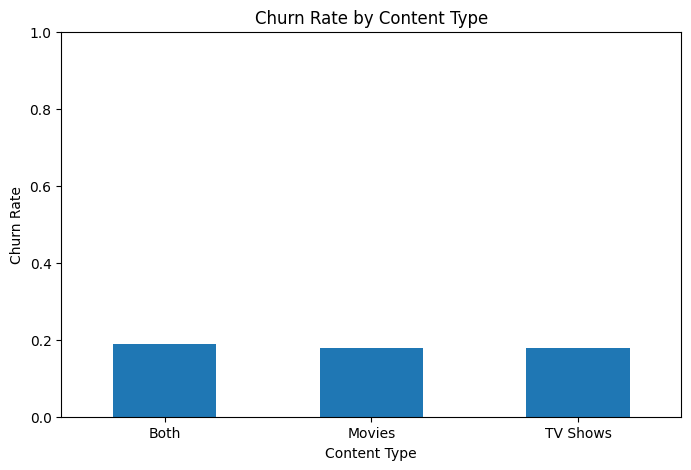

In [74]:
contenttype_churn = (
    df.groupby("ContentType")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

print(contenttype_churn)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

contenttype_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("Content Type")
plt.title("Churn Rate by Content Type")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()

---

MultiDeviceAccess
No     0.181727
Yes    0.180736
Name: Churn, dtype: float64


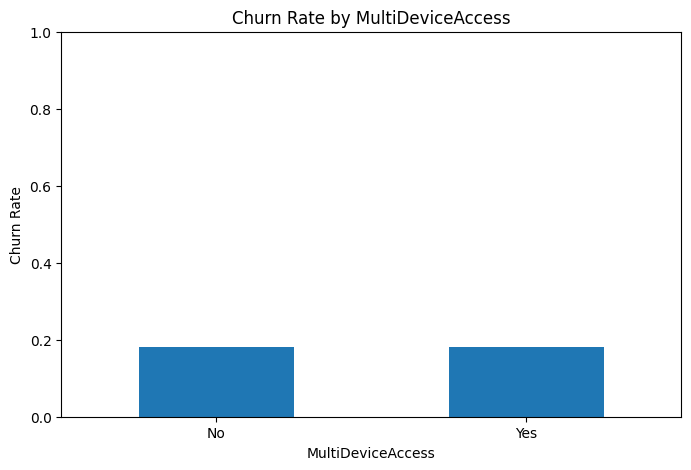

In [75]:
multidevice_churn = (
    df.groupby("MultiDeviceAccess")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

print(multidevice_churn)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

multidevice_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("MultiDeviceAccess")
plt.title("Churn Rate by MultiDeviceAccess")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()



---

DeviceRegistered
Mobile      0.182372
Tablet      0.182147
Computer    0.181350
TV          0.179044
Name: Churn, dtype: float64


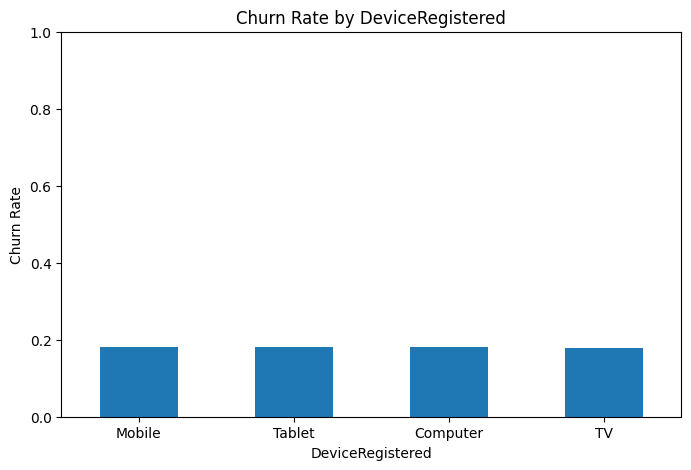

In [76]:
deviceregistered_churn = (
    df.groupby("DeviceRegistered")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

print(deviceregistered_churn)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

deviceregistered_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("DeviceRegistered")
plt.title("Churn Rate by DeviceRegistered")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()



---

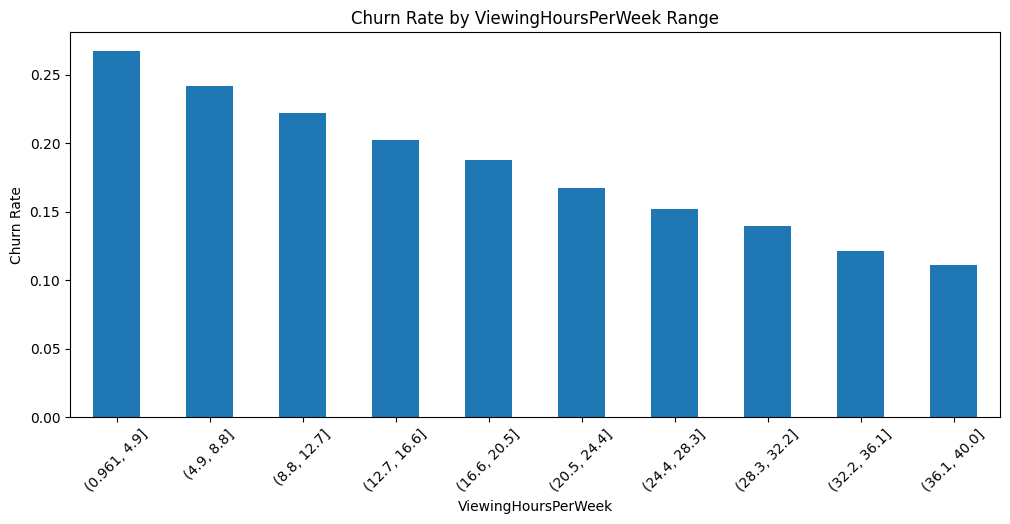

In [77]:
df["ViewingHoursPerWeekGroup"] = pd.cut(
    df["ViewingHoursPerWeek"],
    bins=10
)

monthly_churn = (
    df.groupby("ViewingHoursPerWeekGroup", observed=True)["Churn"]
      .mean()
)

monthly_churn.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Churn Rate")
plt.xlabel("ViewingHoursPerWeek")
plt.title("Churn Rate by ViewingHoursPerWeek Range")

plt.xticks(rotation=45)
plt.show()

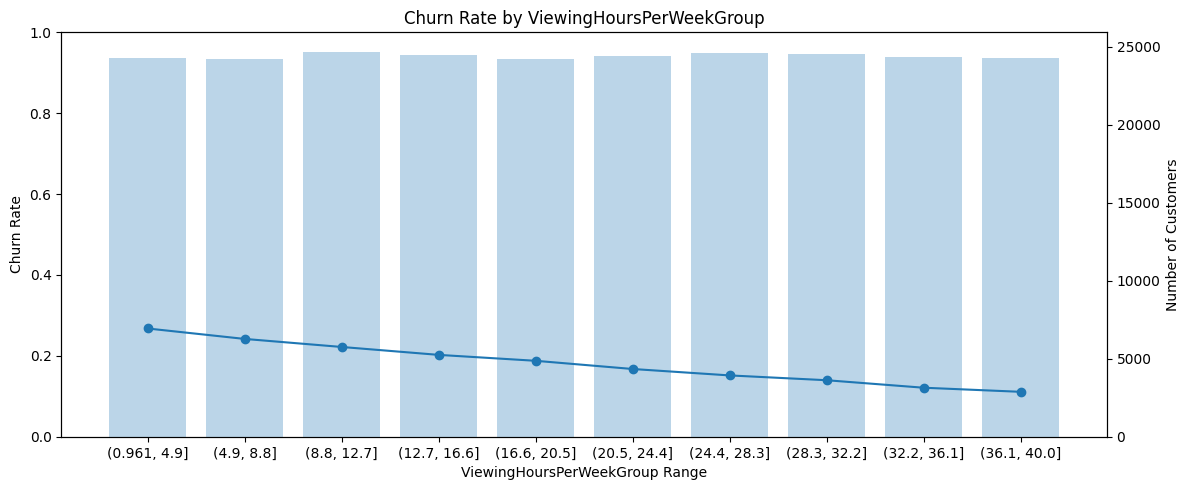

In [78]:
import matplotlib.pyplot as plt

view_hours_per_week_dist = (
    df.assign(
        ViewingHoursPerWeekGroup=pd.cut(
            df["ViewingHoursPerWeek"],
            bins=10
        )
    )
    .groupby("ViewingHoursPerWeekGroup", observed=True)
    .agg(
        churn_rate=("Churn", "mean"),
        customer_count=("Churn", "size")
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(
    view_hours_per_week_dist["ViewingHoursPerWeekGroup"].astype(str),
    view_hours_per_week_dist["churn_rate"],
    marker="o"
)

ax1.set_xlabel("ViewingHoursPerWeekGroup Range")
ax1.set_ylabel("Churn Rate")
ax1.set_ylim(0,1)

ax2 = ax1.twinx()

ax2.bar(
    view_hours_per_week_dist["ViewingHoursPerWeekGroup"].astype(str),
    view_hours_per_week_dist["customer_count"],
    alpha=0.3
)

ax2.set_ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.title("Churn Rate by ViewingHoursPerWeekGroup")
plt.tight_layout()

plt.show()

In [79]:
df[["ViewingHoursPerWeek", "Churn"]].corr()

,ViewingHoursPerWeek,Churn
ViewingHoursPerWeek,1.000000,-0.128645
Churn,-0.128645,1.000000


---

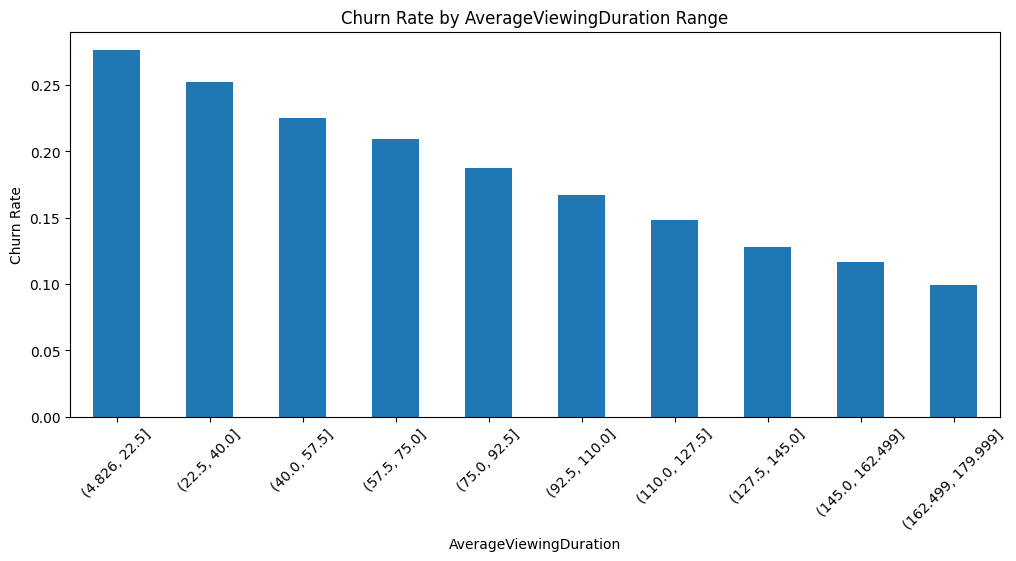

In [80]:
df["AverageViewingDurationGroup"] = pd.cut(
    df["AverageViewingDuration"],
    bins=10
)

monthly_churn = (
    df.groupby("AverageViewingDurationGroup", observed=True)["Churn"]
      .mean()
)

monthly_churn.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Churn Rate")
plt.xlabel("AverageViewingDuration")
plt.title("Churn Rate by AverageViewingDuration Range")

plt.xticks(rotation=45)
plt.show()

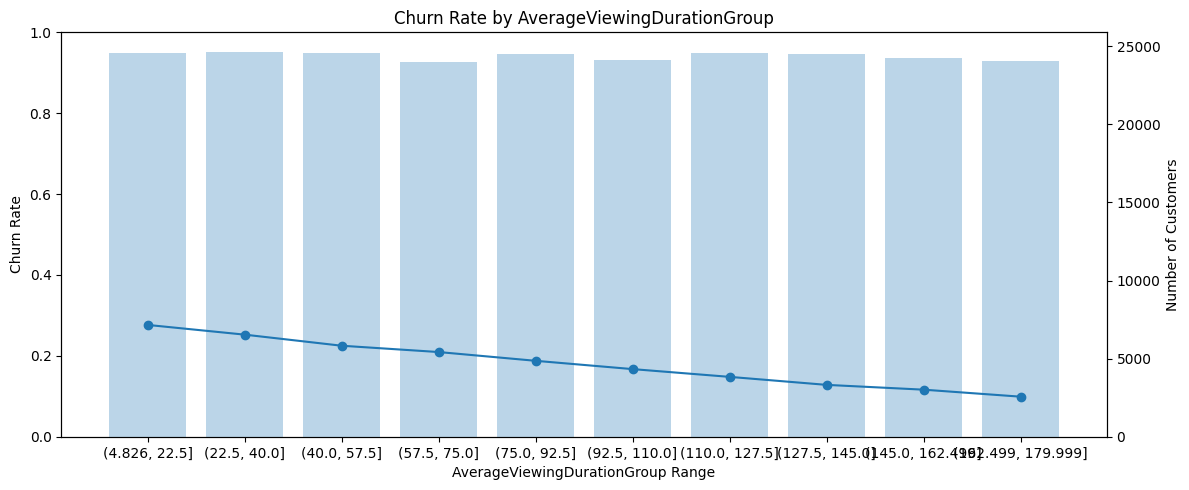

In [81]:
import matplotlib.pyplot as plt

avg_view_duration_dist = (
    df.assign(
        AverageViewingDurationGroup=pd.cut(
            df["AverageViewingDuration"],
            bins=10
        )
    )
    .groupby("AverageViewingDurationGroup", observed=True)
    .agg(
        churn_rate=("Churn", "mean"),
        customer_count=("Churn", "size")
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(
    avg_view_duration_dist["AverageViewingDurationGroup"].astype(str),
    avg_view_duration_dist["churn_rate"],
    marker="o"
)

ax1.set_xlabel("AverageViewingDurationGroup Range")
ax1.set_ylabel("Churn Rate")
ax1.set_ylim(0,1)

ax2 = ax1.twinx()

ax2.bar(
    avg_view_duration_dist["AverageViewingDurationGroup"].astype(str),
    avg_view_duration_dist["customer_count"],
    alpha=0.3
)

ax2.set_ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.title("Churn Rate by AverageViewingDurationGroup")
plt.tight_layout()

plt.show()

In [82]:
df[["AverageViewingDuration", "Churn"]].corr()

,AverageViewingDuration,Churn
AverageViewingDuration,1.000000,-0.146897
Churn,-0.146897,1.000000


---

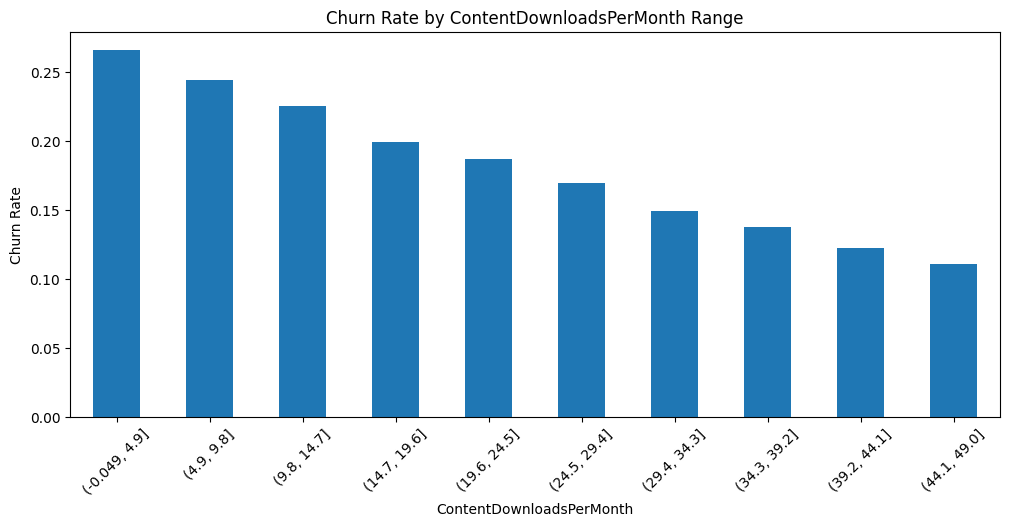

In [83]:
df["ContentDownloadsPerMonthGroup"] = pd.cut(
    df["ContentDownloadsPerMonth"],
    bins=10
)

monthly_churn = (
    df.groupby("ContentDownloadsPerMonthGroup", observed=True)["Churn"]
      .mean()
)

monthly_churn.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Churn Rate")
plt.xlabel("ContentDownloadsPerMonth")
plt.title("Churn Rate by ContentDownloadsPerMonth Range")

plt.xticks(rotation=45)
plt.show()



In [84]:
df[["ContentDownloadsPerMonth", "Churn"]].corr()

,ContentDownloadsPerMonth,Churn
ContentDownloadsPerMonth,1.000000,-0.129752
Churn,-0.129752,1.000000


---

GenrePreference
Comedy     0.193416
Sci-Fi     0.191444
Drama      0.178709
Fantasy    0.176734
Action     0.165866
Name: Churn, dtype: float64


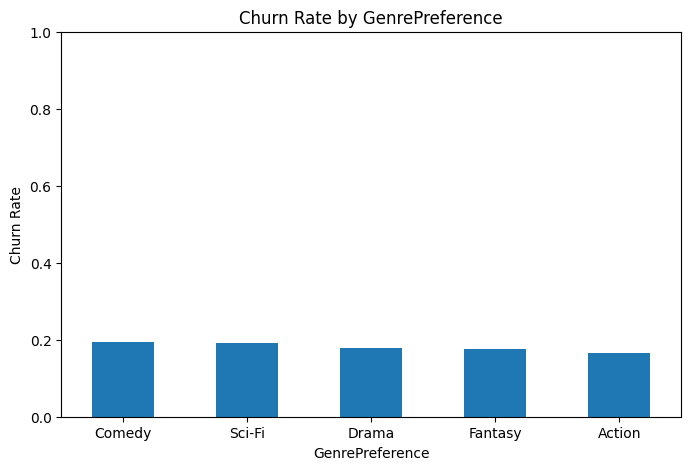

In [85]:
genrepreferences_churn = (
    df.groupby("GenrePreference")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

print(genrepreferences_churn)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

genrepreferences_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("GenrePreference")
plt.title("Churn Rate by GenrePreference")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()



---

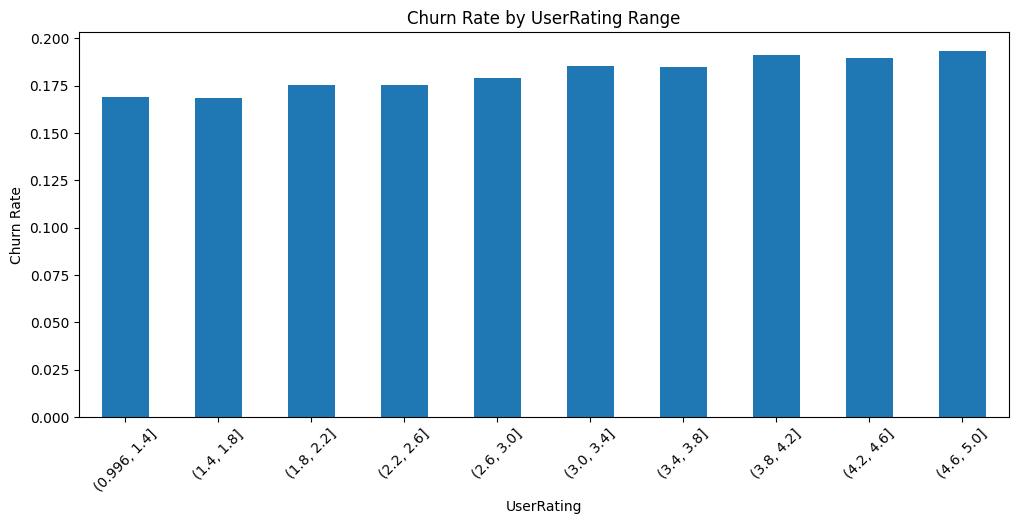

In [86]:
df["UserRatingGroup"] = pd.cut(
    df["UserRating"],
    bins=10
)

monthly_churn = (
    df.groupby("UserRatingGroup", observed=True)["Churn"]
      .mean()
)

monthly_churn.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Churn Rate")
plt.xlabel("UserRating")
plt.title("Churn Rate by UserRating Range")

plt.xticks(rotation=45)
plt.show()



In [87]:
df[["UserRating", "Churn"]].corr()

,UserRating,Churn
UserRating,1.000000,0.022124
Churn,0.022124,1.000000


---

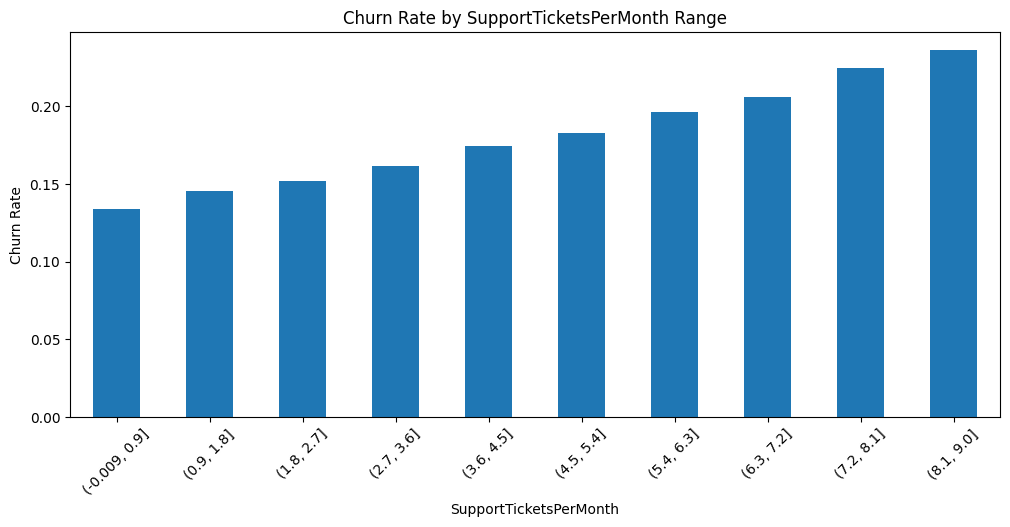

                        SupportTicketsPerMonth     Churn
SupportTicketsPerMonth                1.000000  0.084064
Churn                                 0.084064  1.000000


In [88]:
df["SupportTicketsPerMonthGroup"] = pd.cut(
    df["SupportTicketsPerMonth"],
    bins=10
)

monthly_churn = (
    df.groupby("SupportTicketsPerMonthGroup", observed=True)["Churn"]
      .mean()
)

monthly_churn.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Churn Rate")
plt.xlabel("SupportTicketsPerMonth")
plt.title("Churn Rate by SupportTicketsPerMonth Range")

plt.xticks(rotation=45)
plt.show()

print(df[["SupportTicketsPerMonth", "Churn"]].corr())



---

Gender
Male      0.184109
Female    0.178356
Name: Churn, dtype: float64


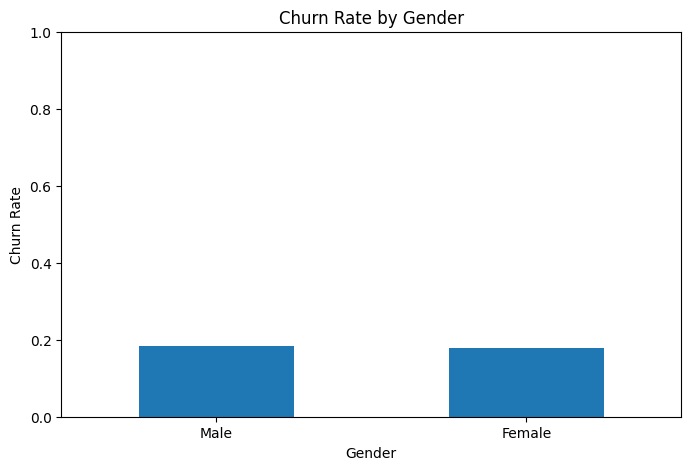

In [89]:
gender_churn = (
    df.groupby("Gender")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

print(gender_churn)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

gender_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("Gender")
plt.title("Churn Rate by Gender")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()



---

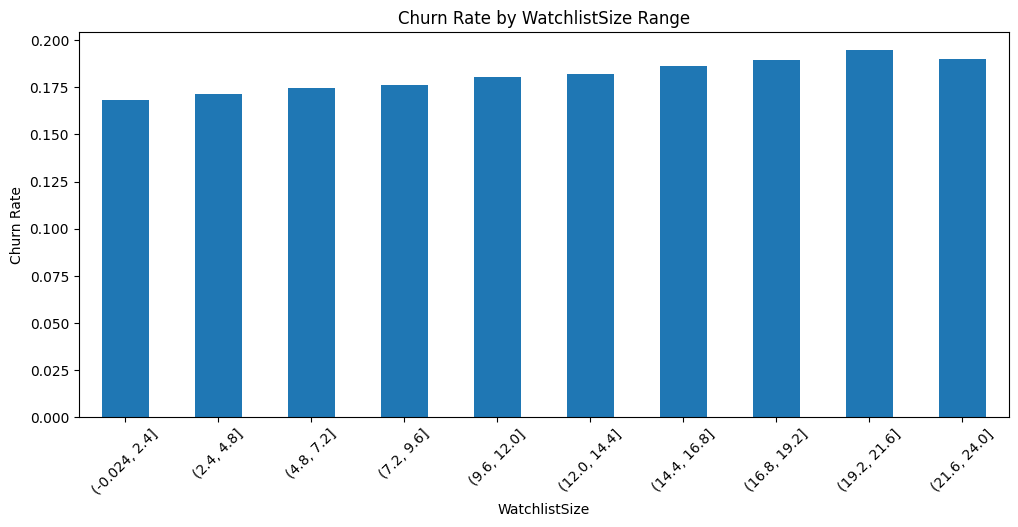

               WatchlistSize     Churn
WatchlistSize       1.000000  0.021739
Churn               0.021739  1.000000


In [90]:
df["WatchlistSizeGroup"] = pd.cut(
    df["WatchlistSize"],
    bins=10
)

monthly_churn = (
    df.groupby("WatchlistSizeGroup", observed=True)["Churn"]
      .mean()
)

monthly_churn.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Churn Rate")
plt.xlabel("WatchlistSize")
plt.title("Churn Rate by WatchlistSize Range")

plt.xticks(rotation=45)
plt.show()

print(df[["WatchlistSize", "Churn"]].corr())



---


ParentalControl
No     0.183366
Yes    0.179105
Name: Churn, dtype: float64


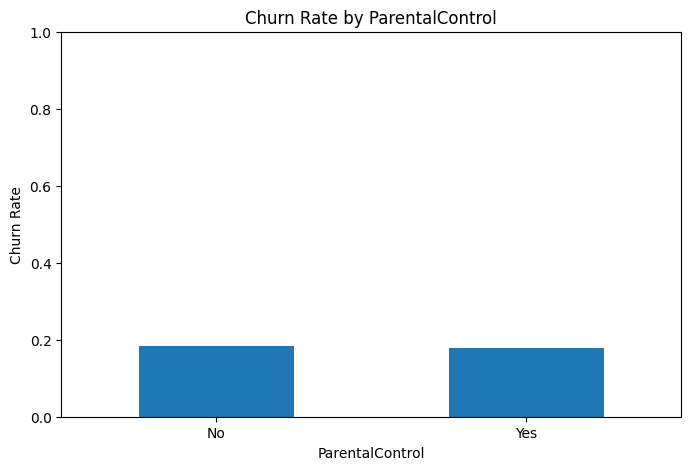

In [91]:
parentalcontrol_churn = (
    df.groupby("ParentalControl")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

print(parentalcontrol_churn)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

parentalcontrol_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("ParentalControl")
plt.title("Churn Rate by ParentalControl")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()



---

SubtitlesEnabled
No     0.186009
Yes    0.176477
Name: Churn, dtype: float64


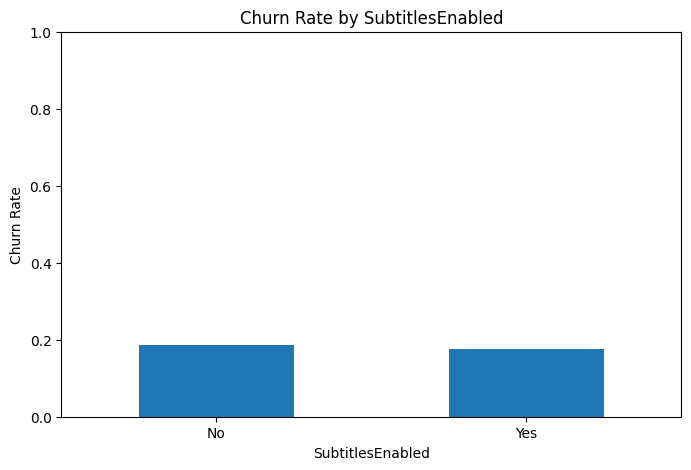

In [92]:
subtitles_churn = (
    df.groupby("SubtitlesEnabled")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

print(subtitles_churn)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

subtitles_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("SubtitlesEnabled")
plt.title("Churn Rate by SubtitlesEnabled")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()


---

# Features vs Features

<Axes: >

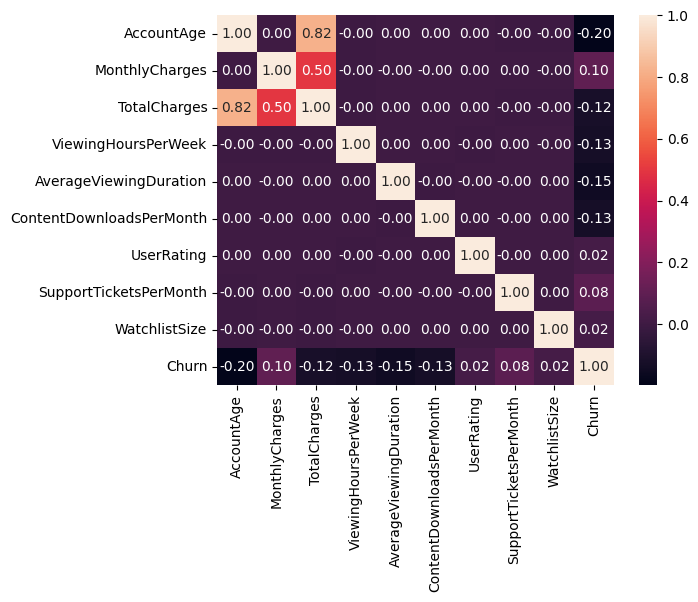

In [93]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")

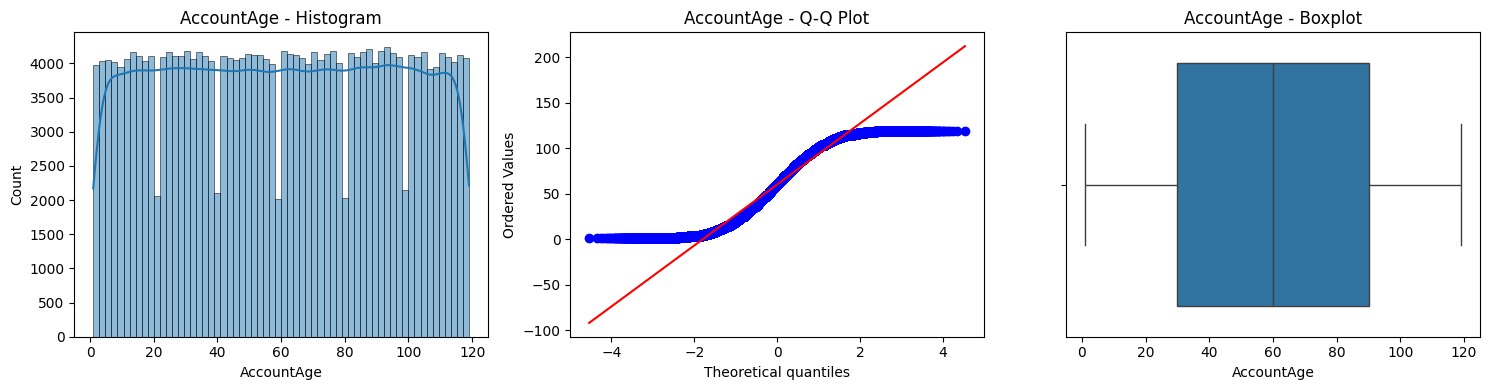

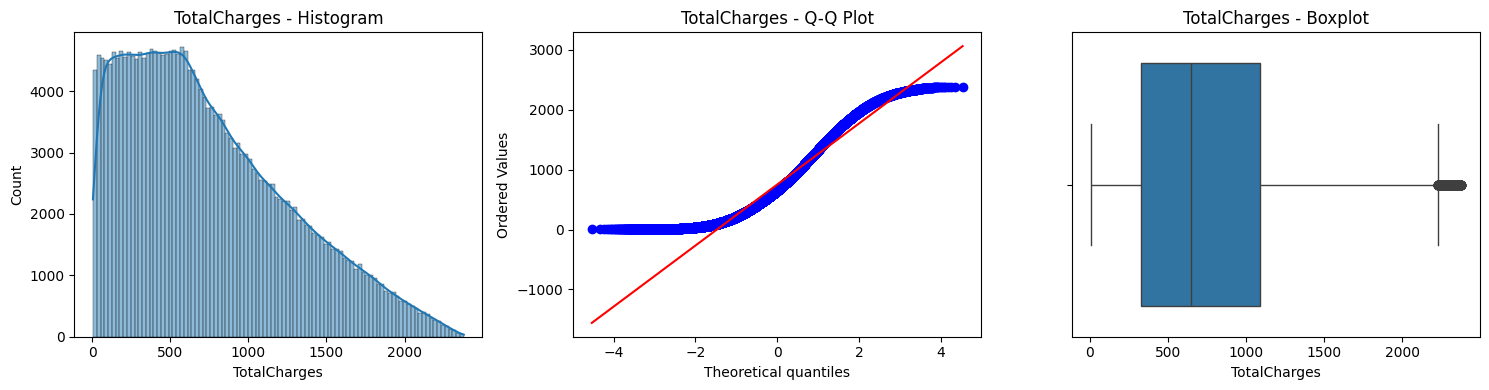

In [94]:
from scipy import stats

for col in ["AccountAge", "TotalCharges"]: 
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"{col} - Histogram")

    stats.probplot(df[col], dist="norm", plot=axes[1])
    axes[1].set_title(f"{col} - Q-Q Plot")

    sns.boxplot(x=df[col], ax=axes[2])
    axes[2].set_title(f"{col} - Boxplot")

    plt.tight_layout()

In [95]:
df["Churn"].value_counts(normalize=True)

Churn
0    0.818768
1    0.181232
Name: proportion, dtype: float64

In [96]:
df.head(5)

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,...,ParentalControl,SubtitlesEnabled,Churn,MonthlyChargesGroup,ViewingHoursPerWeekGroup,AverageViewingDurationGroup,ContentDownloadsPerMonthGroup,UserRatingGroup,SupportTicketsPerMonthGroup,WatchlistSizeGroup
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,...,No,No,0,"(10.99, 12.49]","(36.1, 40.0]","(57.5, 75.0]","(9.8, 14.7]","(1.8, 2.2]","(3.6, 4.5]","(2.4, 4.8]"
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,...,No,Yes,0,"(4.975, 6.49]","(32.2, 36.1]","(22.5, 40.0]","(14.7, 19.6]","(3.4, 3.8]","(7.2, 8.1]","(21.6, 24.0]"
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,...,Yes,Yes,0,"(10.99, 12.49]","(4.9, 8.8]","(40.0, 57.5]","(19.6, 24.5]","(4.2, 4.6]","(5.4, 6.3]","(-0.024, 2.4]"
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,...,Yes,Yes,0,"(6.49, 7.99]","(24.4, 28.3]","(127.5, 145.0]","(29.4, 34.3]","(4.2, 4.6]","(1.8, 2.7]","(21.6, 24.0]"
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,...,No,No,0,"(15.49, 16.99]","(16.6, 20.5]","(40.0, 57.5]","(19.6, 24.5]","(3.4, 3.8]","(3.6, 4.5]","(-0.024, 2.4]"


In [97]:
(df["AccountAge"] == 0).sum()

np.int64(0)

In [98]:
epsilon = 1e-5
df["avg_charge_per_month(AccountAge)"] = df["TotalCharges"] / (df["AccountAge"] + epsilon)

<Axes: >

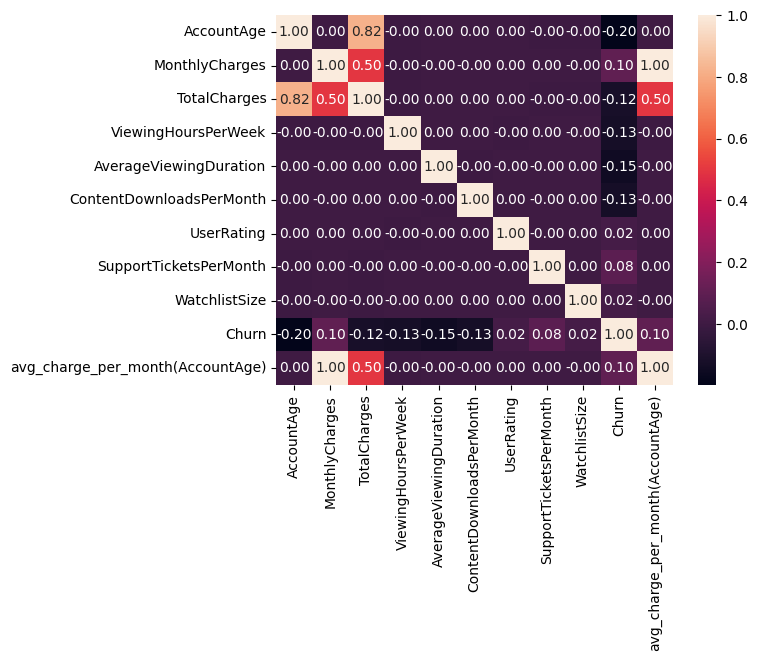

In [99]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243787 entries, 0 to 243786
Data columns (total 28 columns):
 #   Column                            Non-Null Count   Dtype   
---  ------                            --------------   -----   
 0   AccountAge                        243787 non-null  int64   
 1   MonthlyCharges                    243787 non-null  float64 
 2   TotalCharges                      243787 non-null  float64 
 3   SubscriptionType                  243787 non-null  object  
 4   PaymentMethod                     243787 non-null  object  
 5   PaperlessBilling                  243787 non-null  object  
 6   ContentType                       243787 non-null  object  
 7   MultiDeviceAccess                 243787 non-null  object  
 8   DeviceRegistered                  243787 non-null  object  
 9   ViewingHoursPerWeek               243787 non-null  float64 
 10  AverageViewingDuration            243787 non-null  float64 
 11  ContentDownloadsPerMonth          24378

In [102]:
df["avg_charge_per_month(MonthlyCharges)"] = df["TotalCharges"] / df["MonthlyCharges"] + epsilon 

<Axes: >

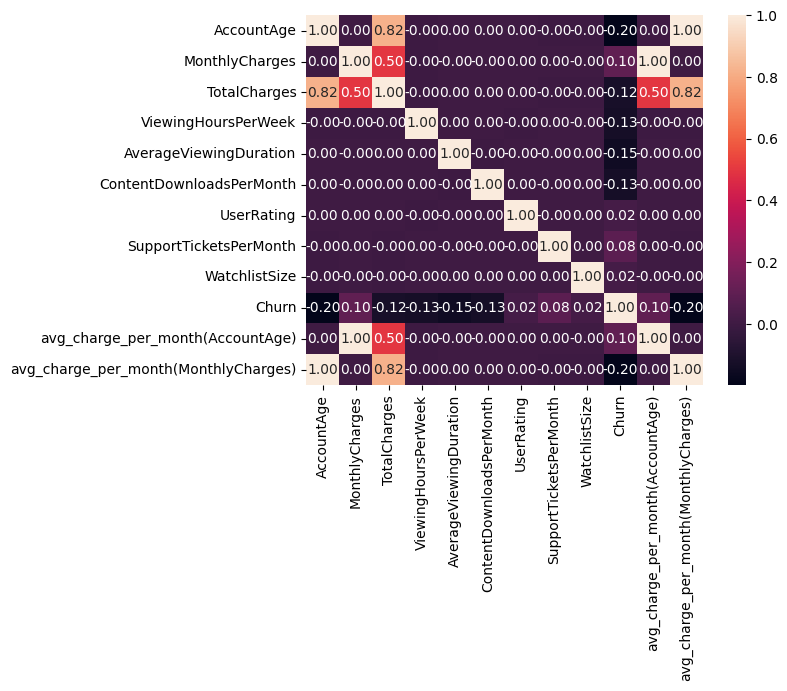

In [103]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
result = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).query("missing_count > 0").sort_values("missing_pct", ascending=False)
print(f"Total rows: {len(df)}")
print(f"Columns with missing values: {len(result)}")
result

In [105]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
result = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).query("missing_count > 0").sort_values("missing_pct", ascending=False)
print(f"Total rows: {len(df)}")
print(f"Columns with missing values: {len(result)}")
result

Total rows: 243787
Columns with missing values: 0


,missing_count,missing_pct


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243787 entries, 0 to 243786
Data columns (total 29 columns):
 #   Column                                Non-Null Count   Dtype   
---  ------                                --------------   -----   
 0   AccountAge                            243787 non-null  int64   
 1   MonthlyCharges                        243787 non-null  float64 
 2   TotalCharges                          243787 non-null  float64 
 3   SubscriptionType                      243787 non-null  object  
 4   PaymentMethod                         243787 non-null  object  
 5   PaperlessBilling                      243787 non-null  object  
 6   ContentType                           243787 non-null  object  
 7   MultiDeviceAccess                     243787 non-null  object  
 8   DeviceRegistered                      243787 non-null  object  
 9   ViewingHoursPerWeek                   243787 non-null  float64 
 10  AverageViewingDuration                243787 non-null  f

In [107]:
cols = ["AccountAge", "MonthlyCharges", "TotalCharges", "avg_charge_per_month(AccountAge)", "avg_charge_per_month(MonthlyCharges)", "Churn"]
df[cols].corr(numeric_only=True)

,AccountAge,MonthlyCharges,TotalCharges,avg_charge_per_month(AccountAge),avg_charge_per_month(MonthlyCharges),Churn
AccountAge,1.000000,0.001706,0.820144,0.001708,1.000000,-0.197736
MonthlyCharges,0.001706,1.000000,0.498207,1.000000,0.001706,0.100473
TotalCharges,0.820144,0.498207,1.000000,0.498209,0.820144,-0.120529
avg_charge_per_month(AccountAge),0.001708,1.000000,0.498209,1.000000,0.001708,0.100472
avg_charge_per_month(MonthlyCharges),1.000000,0.001706,0.820144,0.001708,1.000000,-0.197736
Churn,-0.197736,0.100473,-0.120529,0.100472,-0.197736,1.000000


In [108]:
diff = df["TotalCharges"] - (df["AccountAge"] * df["MonthlyCharges"])
print(diff.describe())
print("\nmax abs diff:", diff.abs().max())

count    2.437870e+05
mean    -8.922406e-16
std      1.020948e-13
min     -1.591616e-12
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.364242e-12
dtype: float64

max abs diff: 1.5916157281026244e-12


In [109]:
df.drop(columns=["TotalCharges", "avg_charge_per_month(AccountAge)", "avg_charge_per_month(MonthlyCharges)"], inplace=True)
print(df.shape)
print(df.columns.tolist())

(243787, 26)
['AccountAge', 'MonthlyCharges', 'SubscriptionType', 'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess', 'DeviceRegistered', 'ViewingHoursPerWeek', 'AverageViewingDuration', 'ContentDownloadsPerMonth', 'GenrePreference', 'UserRating', 'SupportTicketsPerMonth', 'Gender', 'WatchlistSize', 'ParentalControl', 'SubtitlesEnabled', 'Churn', 'MonthlyChargesGroup', 'ViewingHoursPerWeekGroup', 'AverageViewingDurationGroup', 'ContentDownloadsPerMonthGroup', 'UserRatingGroup', 'SupportTicketsPerMonthGroup', 'WatchlistSizeGroup']


In [110]:
corr = df.corr(numeric_only=True)
pairs = (
    corr.where(~np.eye(len(corr), dtype=bool))
    .stack()
    .reset_index()
)
pairs.columns = ["feature_1", "feature_2", "corr"]
pairs = pairs[pairs["feature_1"] < pairs["feature_2"]]
pairs["abs_corr"] = pairs["corr"].abs()
suspicious = pairs[pairs["abs_corr"] > 0.5].sort_values("abs_corr", ascending=False)
suspicious

,feature_1,feature_2,corr,abs_corr


In [111]:
pairs.sort_values("abs_corr", ascending=False).head(10)

,feature_1,feature_2,corr,abs_corr
7,AccountAge,Churn,-0.197736,0.197736
31,AverageViewingDuration,Churn,-0.146897,0.146897
68,Churn,ContentDownloadsPerMonth,-0.129752,0.129752
66,Churn,ViewingHoursPerWeek,-0.128645,0.128645
65,Churn,MonthlyCharges,0.100473,0.100473
70,Churn,SupportTicketsPerMonth,0.084064,0.084064
69,Churn,UserRating,0.022124,0.022124
71,Churn,WatchlistSize,0.021739,0.021739
42,UserRating,ViewingHoursPerWeek,-0.003185,0.003185
9,MonthlyCharges,ViewingHoursPerWeek,-0.003029,0.003029


In [112]:
from scipy.stats import chi2_contingency
import numpy as np

categorical_cols = [
    "SubscriptionType", "PaymentMethod", "PaperlessBilling", "ContentType",
    "MultiDeviceAccess", "DeviceRegistered", "GenrePreference", "Gender",
    "ParentalControl", "SubtitlesEnabled",
]

results = []
for col in categorical_cols:
    contingency = pd.crosstab(df[col], df["Churn"])
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else np.nan
    results.append({"feature": col, "chi2": chi2, "p_value": p, "cramers_v": cramers_v})

cat_summary = pd.DataFrame(results).sort_values("cramers_v", ascending=False)
cat_summary

,feature,chi2,p_value,cramers_v
0,SubscriptionType,318.449356,7.072956e-70,0.036142
1,PaymentMethod,239.863822,1.018485e-51,0.031367
6,GenrePreference,169.296653,1.480532e-35,0.026352
3,ContentType,43.453997,3.665087e-10,0.013351
9,SubtitlesEnabled,37.251633,1.038280e-09,0.012361
7,Gender,13.554239,2.317674e-04,0.007456
8,ParentalControl,7.429245,6.417227e-03,0.005520
5,DeviceRegistered,2.839135,4.170980e-01,0.003413
4,MultiDeviceAccess,0.396155,5.290818e-01,0.001275
2,PaperlessBilling,0.202776,6.524893e-01,0.000912


In [113]:
pd.set_option("display.float_format", lambda x: f"{x:.10f}")
cat_summary

,feature,chi2,p_value,cramers_v
0,SubscriptionType,318.4493559264,0.0000000000,0.0361422276
1,PaymentMethod,239.8638224721,0.0000000000,0.0313672975
6,GenrePreference,169.2966532658,0.0000000000,0.0263523236
3,ContentType,43.4539974881,0.0000000004,0.0133508709
9,SubtitlesEnabled,37.2516330114,0.0000000010,0.0123613922
7,Gender,13.5542390222,0.0002317674,0.0074564532
8,ParentalControl,7.4292447058,0.0064172271,0.0055203557
5,DeviceRegistered,2.8391350446,0.4170980451,0.0034126186
4,MultiDeviceAccess,0.3961548720,0.5290817523,0.0012747565
2,PaperlessBilling,0.2027761841,0.6524892606,0.0009120176


In [114]:
df.drop(columns=["DeviceRegistered", "MultiDeviceAccess", "PaperlessBilling"], inplace=True)
print(df.shape)
print(df.columns.tolist())

(243787, 23)
['AccountAge', 'MonthlyCharges', 'SubscriptionType', 'PaymentMethod', 'ContentType', 'ViewingHoursPerWeek', 'AverageViewingDuration', 'ContentDownloadsPerMonth', 'GenrePreference', 'UserRating', 'SupportTicketsPerMonth', 'Gender', 'WatchlistSize', 'ParentalControl', 'SubtitlesEnabled', 'Churn', 'MonthlyChargesGroup', 'ViewingHoursPerWeekGroup', 'AverageViewingDurationGroup', 'ContentDownloadsPerMonthGroup', 'UserRatingGroup', 'SupportTicketsPerMonthGroup', 'WatchlistSizeGroup']


In [115]:
numeric_cols = [
    "AccountAge", "MonthlyCharges", "ViewingHoursPerWeek", "AverageViewingDuration",
    "ContentDownloadsPerMonth", "UserRating", "SupportTicketsPerMonth", "WatchlistSize",
]

corr_with_churn = df[numeric_cols + ["Churn"]].corr(numeric_only=True)["Churn"].drop("Churn").sort_values(key=abs, ascending=False)
print("Correlation with Churn:")
print(corr_with_churn)

print("\nMean values by Churn group:")
df.groupby("Churn")[numeric_cols].mean().T

Correlation with Churn:
AccountAge                 -0.1977356320
AverageViewingDuration     -0.1468965687
ContentDownloadsPerMonth   -0.1297518742
ViewingHoursPerWeek        -0.1286448060
MonthlyCharges              0.1004728066
SupportTicketsPerMonth      0.0840643308
UserRating                  0.0221235811
WatchlistSize               0.0217386749
Name: Churn, dtype: float64

Mean values by Churn group:


Churn,0,1
AccountAge,63.2732897473,45.6741206826
MonthlyCharges,12.2861285872,13.4148803796
ViewingHoursPerWeek,21.1826970861,17.4277413063
AverageViewingDuration,95.7545334847,76.4948397686
ContentDownloadsPerMonth,25.3838531099,20.5263229369
UserRating,2.9906881416,3.0570374034
SupportTicketsPerMonth,4.3905763884,5.0174505455
WatchlistSize,11.9449412590,12.3508668689


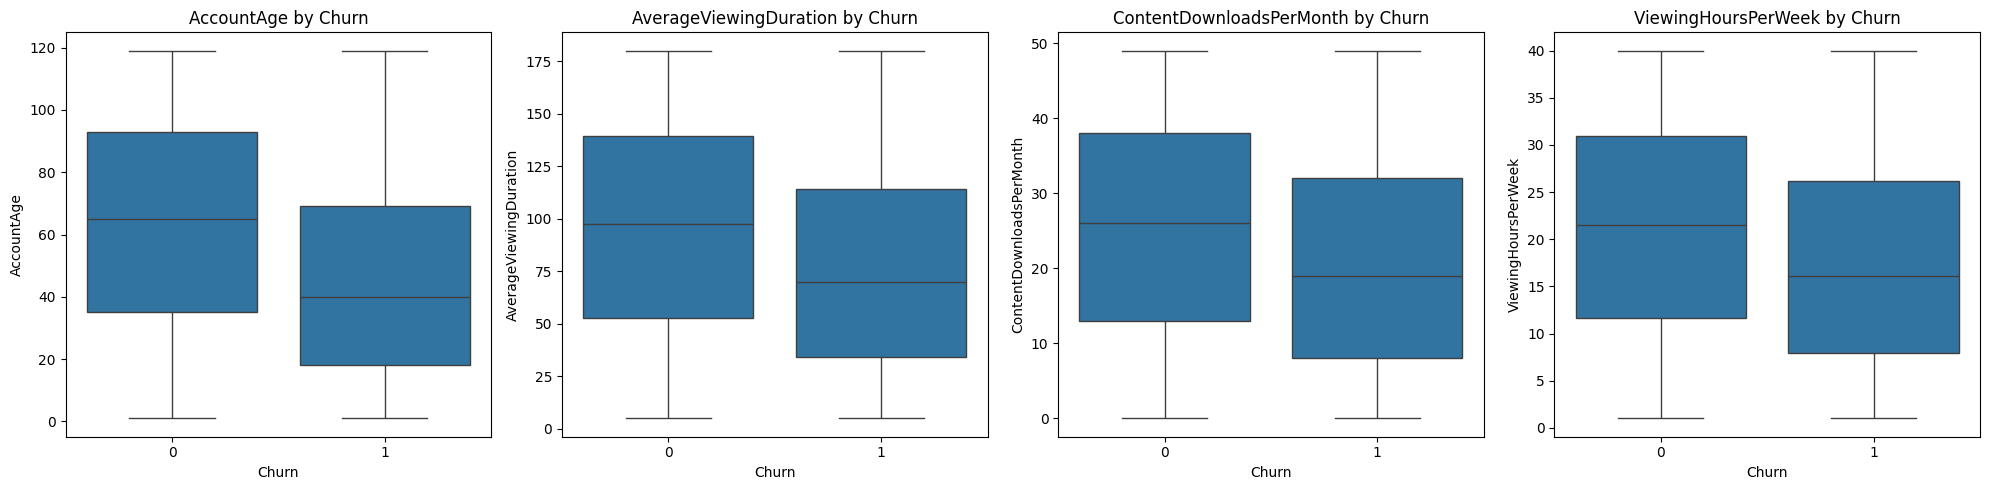

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = ["AccountAge", "AverageViewingDuration", "ContentDownloadsPerMonth", "ViewingHoursPerWeek"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col in zip(axes, top_features):
    sns.boxplot(data=df, x="Churn", y=col, ax=ax)
    ax.set_title(f"{col} by Churn")

plt.tight_layout()
plt.show()

In [118]:
from sklearn.feature_selection import mutual_info_classif

check_cols = ["UserRating", "WatchlistSize", "AccountAge", "AverageViewingDuration"]
mi = mutual_info_classif(df[check_cols], df["Churn"], random_state=42)
pd.Series(mi, index=check_cols).sort_values(ascending=False)

AccountAge               0.0203094191
AverageViewingDuration   0.0099955614
WatchlistSize            0.0018441594
UserRating               0.0004542340
dtype: float64

In [119]:
numeric_cols = [
    "AccountAge", "MonthlyCharges", "ViewingHoursPerWeek", "AverageViewingDuration",
    "ContentDownloadsPerMonth", "UserRating", "SupportTicketsPerMonth", "WatchlistSize",
]

outlier_report = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_report.append({
        "feature": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "n_outliers": len(outliers),
        "pct_outliers": round(len(outliers) / len(df) * 100, 3),
        "min": df[col].min(),
        "max": df[col].max(),
    })

pd.DataFrame(outlier_report).sort_values("pct_outliers", ascending=False)

,feature,lower_bound,upper_bound,n_outliers,pct_outliers,min,max
0,AccountAge,-60.0000000000,180.0000000000,0,0.0000000000,1.0000000000,119.0000000000
1,MonthlyCharges,-2.5108822537,27.4875855665,0,0.0000000000,4.9900615466,19.9899568673
2,ViewingHoursPerWeek,-18.4192122975,59.4025611071,0,0.0000000000,1.0000653891,39.9997231361
3,AverageViewingDuration,-82.9060852829,267.1965276076,0,0.0000000000,5.0005474862,179.9992751177
4,ContentDownloadsPerMonth,-25.5000000000,74.5000000000,0,0.0000000000,0.0000000000,49.0000000000
5,UserRating,-1.0011033867,7.0041136391,0,0.0000000000,1.0000073778,4.9999894122
6,SupportTicketsPerMonth,-5.5000000000,14.5000000000,0,0.0000000000,0.0000000000,9.0000000000
7,WatchlistSize,-12.0000000000,36.0000000000,0,0.0000000000,0.0000000000,24.0000000000
